# 02. groupSHAP Preprocess for Bank Marketing

UCI Bank Marketing データを `bank+marketing.zip` から直接読み込み、カテゴリ列を one-hot encoding して既存 notebook と同じ流れで groupSHAP を確認します。

今回の `bank_merketing_columns_description.csv` は `bank` 系と `bank-additional` 系の定義が一部混在しているため、この notebook では `bank-additional-full.csv` を主データとして使い、列定義 CSV は共通列の説明に使いつつ不足分はデータ本体から補完します。


## ライブラリインポート


In [22]:
import os
from io import BytesIO, TextIOWrapper
from pathlib import Path
import zipfile

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


## データロード


In [23]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
ZIP_PATH = DATA_DIR / "bank+marketing.zip"
COLUMN_DESC_PATH = DATA_DIR / "bank_merketing_columns_description.csv"
DATA_MEMBER = "bank-additional.zip"
INNER_MEMBER = "bank-additional/bank-additional-full.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2


def read_nested_csv_from_zip(zip_path: Path, outer_member: str, inner_member: str, **read_csv_kwargs) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as outer_zip:
        nested_bytes = outer_zip.read(outer_member)
    with zipfile.ZipFile(BytesIO(nested_bytes)) as inner_zip:
        with inner_zip.open(inner_member) as inner_file:
            return pd.read_csv(TextIOWrapper(inner_file, encoding="utf-8"), **read_csv_kwargs)


def read_column_description(csv_path: Path) -> pd.DataFrame:
    rows = []
    with open(csv_path, encoding="utf-8") as f:
        header = next(f).rstrip("\n").split(",")
        for line in f:
            parts = line.rstrip("\n").split(",")
            if len(parts) < 6:
                continue
            rows.append(
                {
                    header[0]: parts[0],
                    header[1]: parts[1],
                    header[2]: parts[2],
                    header[3]: parts[3],
                    header[4]: ",".join(parts[4:-1]).strip(),
                    header[5]: parts[-1],
                }
            )
    return pd.DataFrame(rows, columns=header)


raw_df = read_nested_csv_from_zip(
    ZIP_PATH,
    DATA_MEMBER,
    INNER_MEMBER,
    sep=";",
)
column_desc_df = read_column_description(COLUMN_DESC_PATH)

display(raw_df.head())
display(column_desc_df)
print("data shape:", raw_df.shape)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,Name,Role,Type,Units,Description,Missing Values
0,age,feature,integer,,,No
1,job,feature,categorical,,"type of job (categorical: 'admin.','blue-colla...",No
2,marital,feature,categorical,,"marital status (categorical: 'divorced','marri...",No
3,education,feature,categorical,,"(categorical: 'basic.4y','basic.6y','basic.9y'...",No
4,default,feature,binary,,has credit in default?,No
5,balance,feature,integer,euros,average yearly balance,No
6,housing,feature,binary,,has housing loan?,No
7,loan,feature,binary,,has personal loan?,No
8,contact,feature,categorical,,contact communication type (categorical: 'cell...,Yes
9,day_of_week,feature,date,,last contact day of the week,No


data shape: (41188, 21)


## 列定義の整形

`bank_merketing_columns_description.csv` と実データの列を突き合わせ、足りない定義を補完します。


In [24]:
dataset_columns = raw_df.columns.tolist()
desc_columns = column_desc_df["Name"].tolist()

desc_only_cols = sorted(set(desc_columns) - set(dataset_columns))
data_only_cols = sorted(set(dataset_columns) - set(desc_columns))

supplemental_desc_df = pd.DataFrame(
    [
        {
            "Name": col,
            "Role": "target" if col == "y" else "feature",
            "Type": "numeric",
            "Units": "",
            "Description": f"present in bank-additional dataset but not described in {COLUMN_DESC_PATH.name}",
            "Missing Values": "Unknown",
        }
        for col in data_only_cols
    ]
)

column_info_df = pd.concat(
    [
        column_desc_df[column_desc_df["Name"].isin(dataset_columns)],
        supplemental_desc_df,
    ],
    ignore_index=True,
).drop_duplicates(subset="Name", keep="first")

display(column_info_df.sort_values("Name").reset_index(drop=True))
print("columns only in description file:", desc_only_cols)
print("columns only in dataset:", data_only_cols)


,Name,Role,Type,Units,Description,Missing Values
0,age,feature,integer,,,No
1,campaign,feature,integer,,number of contacts performed during this campa...,No
2,cons.conf.idx,feature,numeric,,present in bank-additional dataset but not des...,Unknown
3,cons.price.idx,feature,numeric,,present in bank-additional dataset but not des...,Unknown
4,contact,feature,categorical,,contact communication type (categorical: 'cell...,Yes
5,day_of_week,feature,date,,last contact day of the week,No
6,default,feature,binary,,has credit in default?,No
7,duration,feature,integer,,"last contact duration, in seconds (numeric). I...",No
8,education,feature,categorical,,"(categorical: 'basic.4y','basic.6y','basic.9y'...",No
9,emp.var.rate,feature,numeric,,present in bank-additional dataset but not des...,Unknown


columns only in description file: ['balance']
columns only in dataset: ['cons.conf.idx', 'cons.price.idx', 'emp.var.rate', 'euribor3m', 'nr.employed']


## 最低限の前処理


In [25]:
target_col = column_info_df.loc[column_info_df["Role"] == "target", "Name"].iloc[0]

numeric_type_labels = {"integer", "numeric", "float", "continuous"}
categorical_type_labels = {"categorical", "binary", "date"}

numeric_cols = column_info_df.loc[
    (column_info_df["Role"] == "feature") & (column_info_df["Type"].isin(numeric_type_labels)),
    "Name",
].tolist()
categorical_cols = column_info_df.loc[
    (column_info_df["Role"] == "feature") & (column_info_df["Type"].isin(categorical_type_labels)),
    "Name",
].tolist()

feature_cols = numeric_cols + categorical_cols

model_df = raw_df[feature_cols + [target_col]].copy()
model_df[categorical_cols] = model_df[categorical_cols].astype("string").apply(lambda s: s.str.strip())
model_df[categorical_cols] = model_df[categorical_cols].fillna("Unknown")
model_df[numeric_cols] = model_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

missing_summary = model_df.isna().mean().sort_values(ascending=False).rename("missing_ratio")

display(pd.Series({"n_rows": len(model_df), "n_features": len(feature_cols), "target_positive_rate": (model_df[target_col] == "yes").mean()}))
display(pd.Series({"n_numeric": len(numeric_cols), "n_categorical": len(categorical_cols)}))
display(missing_summary[missing_summary > 0])
display(model_df[target_col].value_counts(normalize=True).rename("ratio"))


n_rows                  41188.000000
n_features                 20.000000
target_positive_rate        0.112654
dtype: float64

n_numeric        10
n_categorical    10
dtype: int64

Series([], Name: missing_ratio, dtype: float64)

y
no     0.887346
yes    0.112654
Name: ratio, dtype: float64

## train / test split


In [26]:
X_raw = model_df[feature_cols].copy()
y = (model_df[target_col] == "yes").astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

display(pd.Series({"train_rows": len(X_train_raw), "test_rows": len(X_test_raw)}))
display(pd.Series({"train_positive_rate": y_train.mean(), "test_positive_rate": y_test.mean()}))


train_rows    32950
test_rows      8238
dtype: int64

train_positive_rate    0.112656
test_positive_rate     0.112649
dtype: float64

## one-hot encoding


In [27]:
combined_features = pd.concat(
    [
        X_train_raw.assign(_split="train"),
        X_test_raw.assign(_split="test"),
    ],
    ignore_index=True,
)

combined_encoded = pd.get_dummies(
    combined_features,
    columns=categorical_cols,
    dtype=int,
)

train_mask = combined_encoded["_split"] == "train"
X_train = combined_encoded.loc[train_mask].drop(columns="_split").reset_index(drop=True)
X_test = combined_encoded.loc[~train_mask].drop(columns="_split").reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

feature_groups = {col: [col] for col in numeric_cols}
for col in categorical_cols:
    feature_groups[col] = [encoded_col for encoded_col in X_train.columns if encoded_col.startswith(f"{col}_")]

display(pd.Series({k: len(v) for k, v in feature_groups.items()}, name="n_columns"))
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


age                1
duration           1
campaign           1
pdays              1
previous           1
cons.conf.idx      1
cons.price.idx     1
emp.var.rate       1
euribor3m          1
nr.employed        1
job               12
marital            4
education          8
default            3
housing            3
loan               3
contact            2
day_of_week        5
month             10
poutcome           3
Name: n_columns, dtype: int64

X_train: (32950, 63)
X_test: (8238, 63)


## XGBoost ベースライン


In [28]:
baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

baseline_model.fit(X_train, y_train)

test_pred = baseline_model.predict(X_test)
test_proba = baseline_model.predict_proba(X_test)[:, 1]


## ベースライン評価


In [29]:
metrics_df = pd.Series(
    {
        "accuracy": accuracy_score(y_test, test_pred),
        "roc_auc": roc_auc_score(y_test, test_proba),
    },
    name="baseline_score",
).round(4)

display(metrics_df)
print(classification_report(y_test, test_pred, digits=4))


accuracy    0.9243
roc_auc     0.9555
Name: baseline_score, dtype: float64

              precision    recall  f1-score   support

           0     0.9473    0.9685    0.9578      7310
           1     0.6990    0.5754    0.6312       928

    accuracy                         0.9243      8238
   macro avg     0.8231    0.7720    0.7945      8238
weighted avg     0.9193    0.9243    0.9210      8238



## 通常 SHAP

通常 SHAP は one-hot 列ごとの符号付き寄与として扱います。


In [30]:
X_shap = X_test.copy()
explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer(X_shap)

print("SHAP input shape:", X_shap.shape)
print("SHAP values shape:", shap_values.values.shape)


SHAP input shape: (8238, 63)
SHAP values shape: (8238, 63)


## 通常 SHAP summary plot


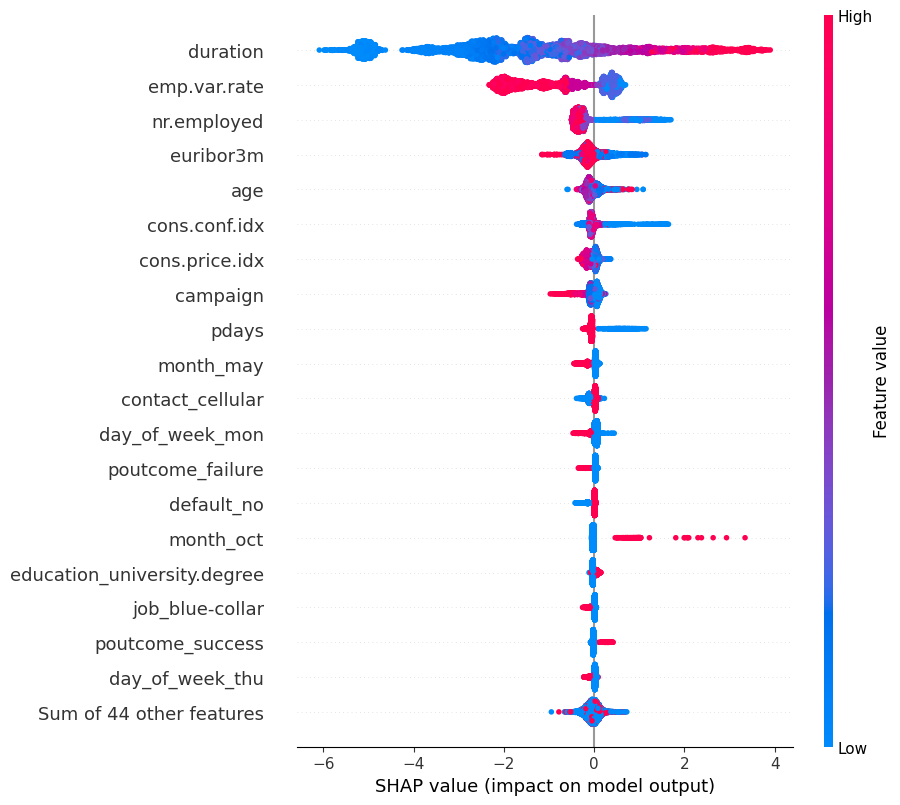

In [31]:
beeswarm_output_path = BASE_DIR / "outputs" / "bank_marketing_shap_beeswarm.png"
beeswarm_output_path.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.savefig(beeswarm_output_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved beeswarm plot to: {beeswarm_output_path}")


## 通常 SHAP importance bar plot


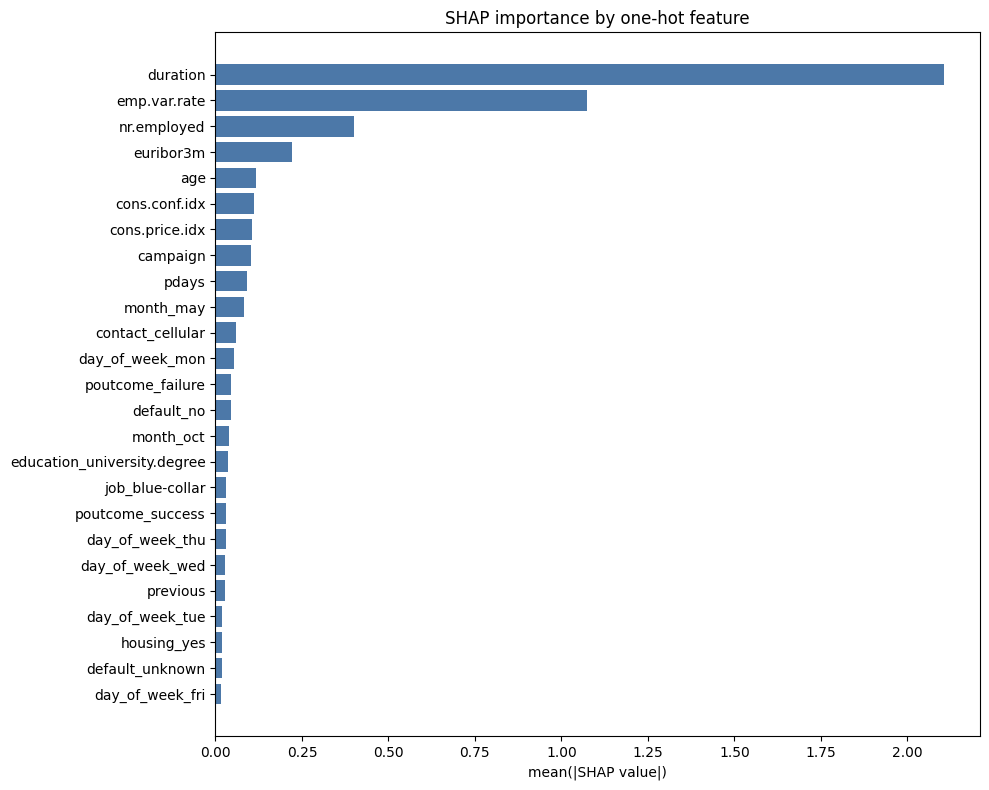

In [32]:
feature_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_shap.columns,
    name="mean_abs_shap",
).sort_values(ascending=False)

top_feature_bar = feature_importance.head(25).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_feature_bar.index, top_feature_bar.values, color="#4C78A8")
ax.set_title("SHAP importance by one-hot feature")
ax.set_xlabel("mean(|SHAP value|)")
ax.set_ylabel("")
plt.tight_layout()


## 群側の absolute aggregation

群側は one-hot 列の `|SHAP|` を元変数単位で足し上げて、カテゴリ変数としての寄与量を見ます。


In [33]:
group_names = list(feature_groups.keys())

group_abs_matrix = np.column_stack(
    [
        np.abs(shap_values.values[:, [X_shap.columns.get_loc(col) for col in feature_groups[group_name]]]).sum(axis=1)
        for group_name in group_names
    ]
)

group_importance = pd.Series(
    group_abs_matrix.mean(axis=0),
    index=group_names,
    name="mean_sum_abs_shap",
).sort_values(ascending=False)

display(group_importance)
print("group absolute matrix:", group_abs_matrix.shape)


duration          2.104945
emp.var.rate      1.073634
nr.employed       0.401696
euribor3m         0.221477
month             0.187103
day_of_week       0.147043
age               0.116274
cons.conf.idx     0.111629
cons.price.idx    0.104262
campaign          0.103981
education         0.103115
job               0.102162
pdays             0.090528
poutcome          0.076970
contact           0.075083
default           0.062294
housing           0.033292
previous          0.026522
marital           0.024943
loan              0.010854
Name: mean_sum_abs_shap, dtype: float32

group absolute matrix: (8238, 20)


## Group Color Mapping


In [34]:
palette = plt.get_cmap("tab20").colors
group_color_map = {
    group_name: to_hex(palette[i % len(palette)])
    for i, group_name in enumerate(feature_groups.keys())
}

feature_to_group = {
    feature_name: group_name
    for group_name, feature_list in feature_groups.items()
    for feature_name in feature_list
}

display(pd.Series(group_color_map, name="color"))


age               #1f77b4
duration          #aec7e8
campaign          #ff7f0e
pdays             #ffbb78
previous          #2ca02c
cons.conf.idx     #98df8a
cons.price.idx    #d62728
emp.var.rate      #ff9896
euribor3m         #9467bd
nr.employed       #c5b0d5
job               #8c564b
marital           #c49c94
education         #e377c2
default           #f7b6d2
housing           #7f7f7f
loan              #c7c7c7
contact           #bcbd22
day_of_week       #dbdb8d
month             #17becf
poutcome          #9edae5
Name: color, dtype: str

## 色分けした群側 bar plot


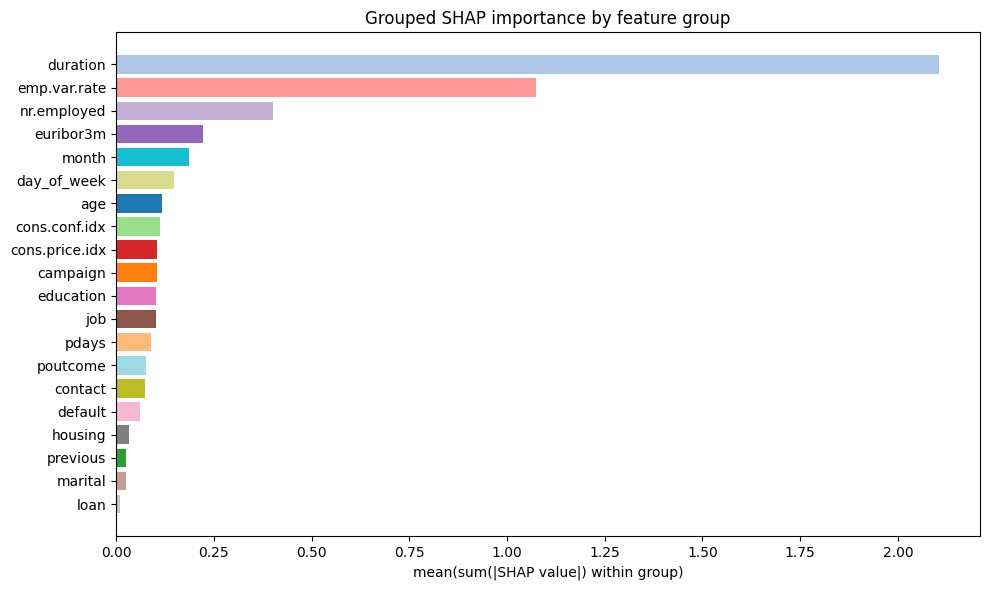

In [35]:
group_bar = group_importance.sort_values(ascending=True)
group_colors = [group_color_map[group_name] for group_name in group_bar.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(group_bar.index, group_bar.values, color=group_colors)
ax.set_title("Grouped SHAP importance by feature group")
ax.set_xlabel("mean(sum(|SHAP value|) within group)")
ax.set_ylabel("")
plt.tight_layout()


## 色分けした通常 SHAP bar plot

通常 SHAP 側も所属グループの色で塗ることで、one-hot 列と群側の対応を追いやすくします。


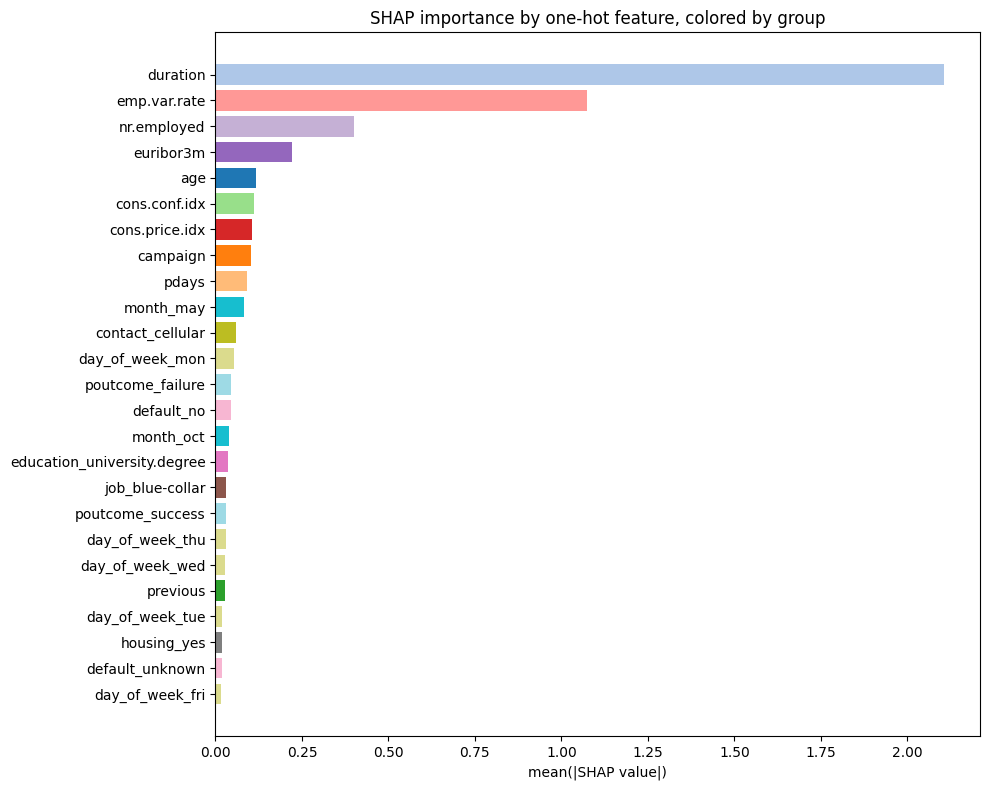

In [36]:
top_feature_bar = feature_importance.head(25).sort_values(ascending=True)
top_feature_colors = [group_color_map[feature_to_group[feature_name]] for feature_name in top_feature_bar.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_feature_bar.index, top_feature_bar.values, color=top_feature_colors)
ax.set_title("SHAP importance by one-hot feature, colored by group")
ax.set_xlabel("mean(|SHAP value|)")
ax.set_ylabel("")
plt.tight_layout()


## PartitionExplainer で groupSHAP を直接近似する

ここでは one-hot 列を後から集約する代わりに、説明時の coalition を元特徴グループ単位に制約します。


In [37]:
GROUP_SHAP_BACKGROUND_SIZE = 200
GROUP_SHAP_EXPLAIN_SIZE = 1000
GROUP_SHAP_MAX_EVALS = 500
GROUP_SHAP_BATCH_SIZE = 50

group_feature_groups = {col: [col] for col in numeric_cols}
for col in categorical_cols:
    group_feature_groups[col] = [
        encoded_col
        for encoded_col in X_train.columns
        if encoded_col.startswith(f"{col}_") and encoded_col not in numeric_cols
    ]

covered_columns = [col for cols in group_feature_groups.values() for col in cols]
assert len(covered_columns) == len(set(covered_columns)) == X_train.shape[1]

display(pd.Series({k: len(v) for k, v in group_feature_groups.items()}, name="n_columns"))
print("background size:", min(GROUP_SHAP_BACKGROUND_SIZE, len(X_train)))
print("explain size:", min(GROUP_SHAP_EXPLAIN_SIZE, len(X_test)))


age                1
duration           1
campaign           1
pdays              1
previous           1
cons.conf.idx      1
cons.price.idx     1
emp.var.rate       1
euribor3m          1
nr.employed        1
job               12
marital            4
education          8
default            3
housing            3
loan               3
contact            2
day_of_week        5
month             10
poutcome           3
Name: n_columns, dtype: int64

background size: 200
explain size: 1000


In [38]:
def build_group_linkage(feature_names, feature_groups, within_distance=1.0, between_distance_start=10.0):
    feature_index = {name: i for i, name in enumerate(feature_names)}
    next_node_id = len(feature_names)
    node_sizes = {i: 1 for i in range(len(feature_names))}
    linkage_rows = []
    group_roots = []

    def merge_many(node_ids, distance):
        nonlocal next_node_id
        current = node_ids[0]
        for node_id in node_ids[1:]:
            merged_size = node_sizes[current] + node_sizes[node_id]
            linkage_rows.append([current, node_id, distance, merged_size])
            node_sizes[next_node_id] = merged_size
            current = next_node_id
            next_node_id += 1
        return current

    for group_name, group_columns in feature_groups.items():
        node_ids = [feature_index[col] for col in group_columns]
        if not node_ids:
            raise ValueError(f"group '{group_name}' has no columns")
        root_id = merge_many(node_ids, within_distance) if len(node_ids) > 1 else node_ids[0]
        group_roots.append(root_id)

    current_root = group_roots[0]
    distance = between_distance_start
    for group_root in group_roots[1:]:
        merged_size = node_sizes[current_root] + node_sizes[group_root]
        linkage_rows.append([current_root, group_root, distance, merged_size])
        node_sizes[next_node_id] = merged_size
        current_root = next_node_id
        next_node_id += 1
        distance += 1.0

    return np.asarray(linkage_rows, dtype=float)


group_feature_names = X_train.columns.tolist()
group_feature_index = {name: i for i, name in enumerate(group_feature_names)}
group_linkage = build_group_linkage(group_feature_names, group_feature_groups)

background_group = X_train.sample(
    min(GROUP_SHAP_BACKGROUND_SIZE, len(X_train)),
    random_state=RANDOM_STATE,
)
X_group_shap = X_test.sample(
    min(GROUP_SHAP_EXPLAIN_SIZE, len(X_test)),
    random_state=RANDOM_STATE,
)


def predict_proba_positive(data):
    if isinstance(data, pd.DataFrame):
        data_df = data.reindex(columns=group_feature_names)
    else:
        data_df = pd.DataFrame(data, columns=group_feature_names)
    return baseline_model.predict_proba(data_df)[:, 1]


group_masker = shap.maskers.Partition(background_group, clustering=group_linkage)
group_explainer = shap.Explainer(
    predict_proba_positive,
    masker=group_masker,
    algorithm="partition",
    feature_names=group_feature_names,
)
group_shap_detail = group_explainer(
    X_group_shap,
    max_evals=GROUP_SHAP_MAX_EVALS,
    batch_size=GROUP_SHAP_BATCH_SIZE,
)

group_phi = pd.DataFrame(
    {
        group_name: group_shap_detail.values[:, [group_feature_index[col] for col in cols]].sum(axis=1)
        for group_name, cols in group_feature_groups.items()
    },
    index=X_group_shap.index,
)

group_shap_importance = group_phi.abs().mean().sort_values(ascending=False)
group_sum_abs_approx = pd.Series(
    {
        group_name: np.abs(
            shap_values.values[X_group_shap.index][:, [X_shap.columns.get_loc(col) for col in cols]].sum(axis=1)
        ).mean()
        for group_name, cols in group_feature_groups.items()
    },
    name="mean_abs_group_sum_from_tree_shap",
).sort_values(ascending=False)

group_comparison = pd.concat(
    [
        group_shap_importance.rename("mean_abs_group_shap"),
        group_sum_abs_approx,
    ],
    axis=1,
)

display(group_comparison)
print("group linkage shape:", group_linkage.shape)
print("group SHAP leaf matrix:", group_shap_detail.values.shape)
print("group phi matrix:", group_phi.shape)
print(
    "max additive residual:",
    np.max(np.abs(group_phi.sum(axis=1).values - group_shap_detail.values.sum(axis=1))),
)


PartitionExplainer explainer: 1001it [06:40,  2.43it/s]                          


,mean_abs_group_shap,mean_abs_group_sum_from_tree_shap
job,0.060159,0.060951
marital,0.020011,0.015628
education,0.010989,0.064400
contact,0.006509,0.075127
month,0.006052,0.109683
day_of_week,0.005251,0.092344
duration,0.005013,2.139931
age,0.005013,0.117241
pdays,0.005013,0.086834
campaign,0.005013,0.105669


group linkage shape: (62, 4)
group SHAP leaf matrix: (1000, 63)
group phi matrix: (1000, 20)
max additive residual: 4.440892098500626e-16


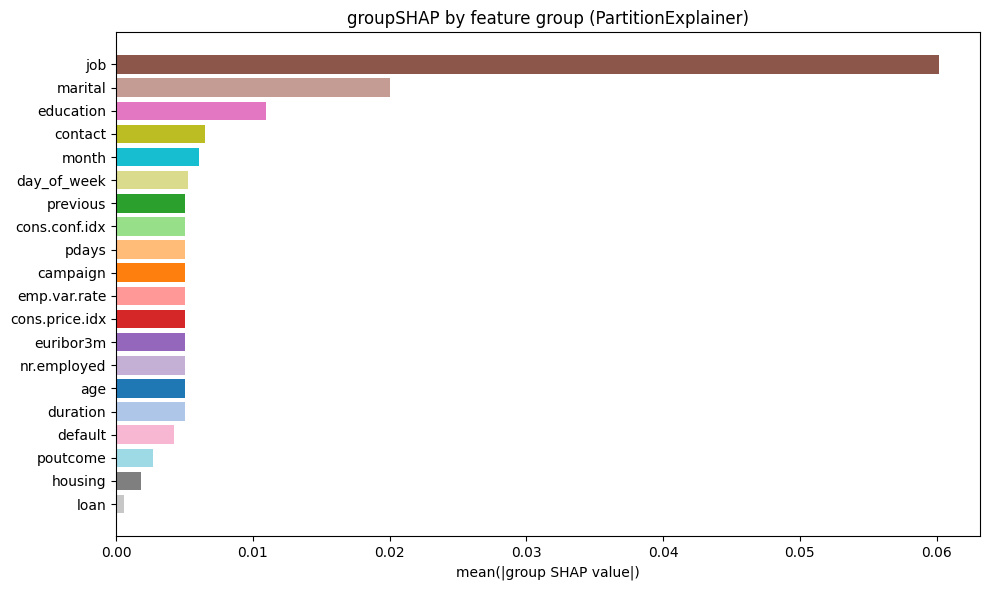

In [42]:
group_bar_exact = group_shap_importance.sort_values(ascending=True)
group_colors_exact = [group_color_map[group_name] for group_name in group_bar_exact.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(group_bar_exact.index, group_bar_exact.values, color=group_colors_exact)
ax.set_title("groupSHAP by feature group (PartitionExplainer)")
ax.set_xlabel("mean(|group SHAP value|)")
ax.set_ylabel("")
plt.tight_layout()


## 色分けした通常 SHAP signed bar plot

one-hot 列ごとの平均 SHAP 値を符号付きで集計し、0 を中心に左右へ伸びる bar plot として表示します。


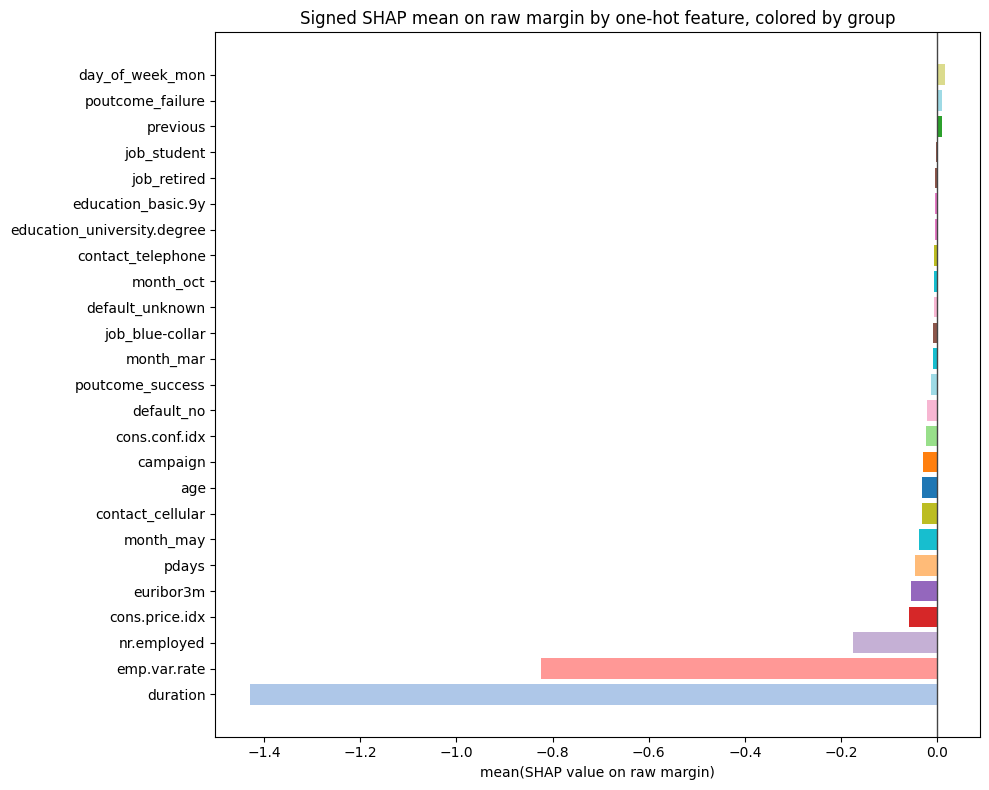

In [43]:
signed_feature_importance = pd.Series(
    shap_values.values.mean(axis=0),
    index=X_shap.columns,
    name="mean_shap",
)

top_signed_feature_bar = signed_feature_importance.reindex(
    signed_feature_importance.abs().sort_values(ascending=False).head(25).index
).sort_values()
top_signed_feature_colors = [group_color_map[feature_to_group[feature_name]] for feature_name in top_signed_feature_bar.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_signed_feature_bar.index, top_signed_feature_bar.values, color=top_signed_feature_colors)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_title("Signed SHAP mean on raw margin by one-hot feature, colored by group")
ax.set_xlabel("mean(SHAP value on raw margin)")
ax.set_ylabel("")
plt.tight_layout()


## 標準化した OLS 係数の可視化

`statsmodels` は使わず、`sklearn.linear_model.LinearRegression` で OLS 相当の線形回帰を当てます。係数比較をしやすくするため、ここでは one-hot 後の特徴量も含めて標準化してから学習します。


emp.var.rate        -0.295671
cons.price.idx       0.139034
duration             0.119578
euribor3m            0.107258
month_aug            0.037460
pdays               -0.034539
month_mar            0.030583
month_jun           -0.021406
poutcome_success     0.021344
month_may           -0.021281
cons.conf.idx        0.016348
contact_telephone   -0.012152
contact_cellular     0.012152
poutcome_failure    -0.009777
month_nov           -0.009013
month_jul            0.008989
previous            -0.008327
job_retired          0.006675
nr.employed          0.006604
job_blue-collar     -0.004676
Name: ols_coef, dtype: float64

intercept: 0.11265553869499116
train R^2: 0.3519065274415857
test R^2: 0.3817233633874061


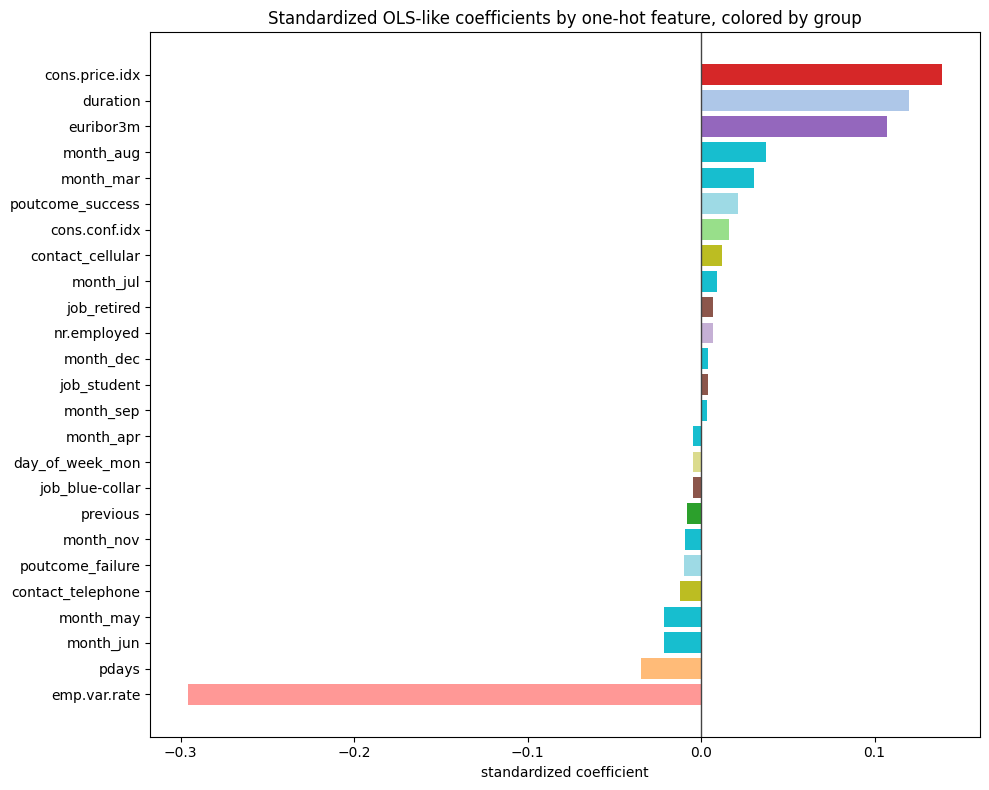

In [44]:
ols_scaler = StandardScaler()
X_train_ols = pd.DataFrame(
    ols_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_ols = pd.DataFrame(
    ols_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

ols_model = LinearRegression()
ols_model.fit(X_train_ols, y_train)

ols_coef = pd.Series(
    ols_model.coef_,
    index=X_train_ols.columns,
    name="ols_coef",
)

top_ols_coef = ols_coef.reindex(ols_coef.abs().sort_values(ascending=False).head(25).index).sort_values()
top_ols_colors = [group_color_map[feature_to_group[feature_name]] for feature_name in top_ols_coef.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_ols_coef.index, top_ols_coef.values, color=top_ols_colors)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_title("Standardized OLS-like coefficients by one-hot feature, colored by group")
ax.set_xlabel("standardized coefficient")
ax.set_ylabel("")
plt.tight_layout()

display(ols_coef.sort_values(key=lambda s: s.abs(), ascending=False).head(20))
print("intercept:", ols_model.intercept_)
print("train R^2:", ols_model.score(X_train_ols, y_train))
print("test R^2:", ols_model.score(X_test_ols, y_test))
